# Do allergy stocks bloom with the pollen? 🤧
### The "buy the antihistamine names before spring" trade — a tidy demand-seasonality story, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Spring seasonal%3F: Not supported](https://img.shields.io/badge/Spring_seasonal%3F-Not_supported-8b949e?style=flat-square)

Every spring, some corner of the market repeats a very sensible-sounding idea: buy the companies that own the big allergy brands *before* pollen season. The logic is clean — from March through May, tens of millions of US hay-fever sufferers restock Claritin, Allegra, Zyrtec, Benadryl and Flonase, a demand spike the industry's own sales data shows every single year. If that seasonal is real and predictable, the brand owners' share prices should carry it too.

So we built the basket — **Bayer** (Claritin), **Sanofi** (Allegra), **Perrigo** (the store-brand pills), **Kenvue** (Zyrtec/Benadryl) and **Haleon** (Flonase) — pinned a **cited pollen-season window** (end of February to end of May), and asked: across **30 springs since 1997**, did the basket actually beat the market? And could you have traded it?

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo, the bootstrap CI and the costed timer? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pollen_season import data, strategy as st

YEARS = data.sample_years()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    TBL = st.build_spread_table(PRICES, YEARS)
    ABN = TBL["abn"].to_numpy()
else:
    PRICES = TBL = ABN = None
print("real cache present:", HAVE_REAL, "| spring windows in sample:", len(YEARS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 30, 'cal_lo': 1997, 'cal_hi': 2026, 'season_label': 'last session of February -> last session on/before May 31', 'abn_mean_pct': 2.03, 'abn_t': 1.06, 'abn_sd_pct': 10.47, 'hit': 19, 'hit_n': 30, 'hit_pct': 63.3, 'wilson': (45.5, 78.1), 'boot_lo_pct': -1.71, 'boot_hi_pct': 5.63, 'placebo_obs_bps': 203.0, 'placebo_mean_bps': -107.0, 'placebo_sd_bps': 182.2, 'placebo_p': 0.048, 'placebo_draws': 5000, 'xlp_mean_pct': 3.58, 'xlp_t': 1.65, 'xlp_n': 28, 'core_mean_pct': 2.02, 'core_t': 1.06, 'core_n': 30, 'gross_bps': 203.0, 'gross_t': 1.06, 'net5_bps': 170.4, 'net5_t': 0.89, 'net10_bps': 150.4, 'net10_t': 0.79, 'borrow_bps': 12.6, 'months': {1: (0.7, 0.12), 2: (-4.6, -0.78), 3: (2.9, 0.57), 4: (4.1, 0.74), 5: (-1.4, -0.28), 6: (-0.5, -0.11), 7: (-3.7, -0.71), 8: (-6.8, -1.31), 9: (4.1, 0.84), 10: (-9.3, -1.62), 11: (-4.5, -0.82), 12: (4.4, 0.95)}, 'years_abn': {1997: -12.09, 1998: 3.95, 1999: 3.96, 2000: -16.8, 2001: 9.04, 2002: 18.09, 2003: 21.02, 2004: 3.83, 2005: 0.48, 2006: 10.72, 2007: 10.22, 2008: 5.97, 2009: 3.03, 2010: -1.58, 2011: 11.78, 2012: -1.21, 2013: 1.51, 2014: -5.48, 2015: 8.02, 2016: -16.05, 2017: 10.75, 2018: -0.84, 2019: -10.93, 2020: 2.66, 2021: 4.03, 2022: 20.19, 2023: -6.1, 2024: -0.45, 2025: 5.21, 2026: -22.01}, 'syn_null_mean': -0.07, 'syn_null_sd': 1.09, 'syn_null_fire': 2, 'syn_planted_t': 4.56, 'syn_planted_pct': 9.3, 'fp_bayry': '09ea36482502', 'fp_sny': '063cf5d088aa', 'fp_prgo': 'f10b7c3e080d', 'fp_kvue': '5f77bcceb9b7', 'fp_hln': 'b95efb29b67e', 'fp_spy': '6685430bd981', 'fp_xlp': '2d7f448f48d3'}


real cache present: True | spring windows in sample: 31


## The answer first

| Question | Answer |
|---|---|
| Does the allergy basket beat the market in spring? | **A little — but not reliably.** The basket beats the market by **+2.03%** on the average spring, and wins in **63%** of years — the right direction. But over 30 springs that average is statistically **indistinguishable from zero**. |
| Is spring genuinely *special* for these stocks? | **Barely, and for a sneaky reason.** Spring beats a *random* stretch of the year — but mostly because the basket quietly **lags the market the rest of the year**, not because spring itself is a goldmine. |
| Could you trade it? | **No edge to bank.** A long-basket / short-market seasonal earns about **+2%/yr gross** — but you can't tell it apart from zero *before* costs, and costs + borrow only make it worse. |

> A genuinely intuitive, real-world demand story — that the tape leans toward but simply won't confirm at this sample size.

## 1 · The claim

> *"Hay-fever season is as predictable as the calendar. Every March the trees start pollinating, drugstores fill their front tables with antihistamines, and the companies that own those brands sell a season's worth of Claritin and Zyrtec. Get in before the sneezing starts and ride the seasonal demand."*

It's not a crazy story — the OTC industry (CHPA/IRI category data) really does show a large, repeatable **cough-cold-allergy** sales spike every spring. The question isn't whether people buy more allergy medicine in spring (they clearly do); it's whether that **known, calendar-predictable** demand is already baked into the share price — or leaves a tradable seasonal behind.

## 2 · So what?

If a **calendar-known** demand spike left a predictable seasonal in the stock, that would be a small dent in market efficiency you could set your watch to — no forecasting skill required, just a date. That's exactly why it's worth checking: an effect this *easy* to see should be arbitraged away if markets are doing their job. So we ask two plain things: did the basket beat the market through the pollen window, and is spring actually different from any other three months?

## 3 · How would we even know?

- **The window.** A cited pollen-season calendar rule: enter at the **last session of February -> last session on/before May 31** (AAFA/AAAAI pollen calendars). It's fixed years in advance, so there's **nothing to predict** — you always know when spring is.
- **The basket.** Five listed allergy-brand owners, equal-weighted (Bayer/Claritin, Sanofi/Allegra, Perrigo/store-brand, Kenvue/Zyrtec, Haleon/Flonase). Two are recent spin-offs, so they only join once they're actually listed — no cheating with backfilled history.
- **The comparison.** The basket's total return over the window vs the market's (SPY), across **30 springs 1997→2026** — one number per year, because each spring is an independent event.
- **The luck check.** Draw same-length windows at *random* points in the year, thousands of times — is spring really different, or is +2% just what a noisy 3-month bet looks like?
- **The trade check.** Go long the basket, short the market, over the window only — pay the spread on both legs, pay borrow on the short — and see if anything survives.

## 4 · The teardown — let's actually look

**First, the headline.** How much did the basket beat the market by, spring by spring, over 30 years?

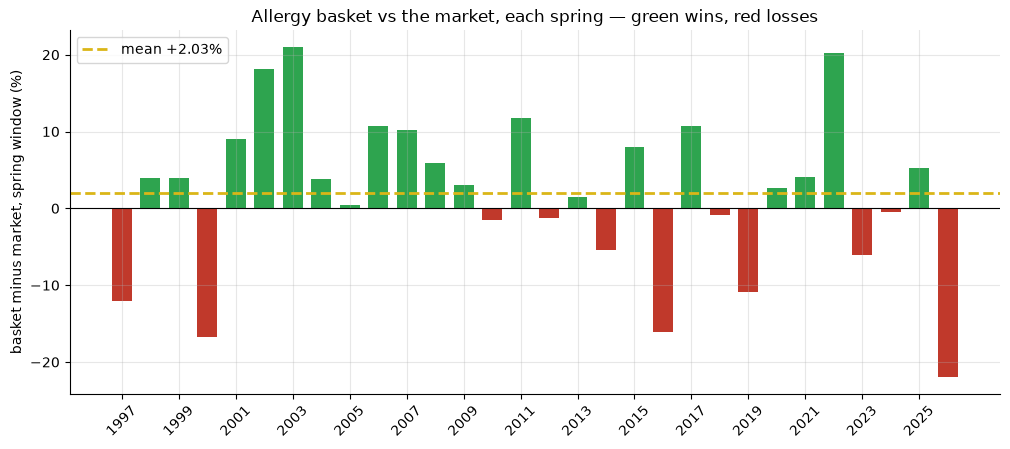

mean spring abnormal return: +2.03%  |  won 19/30 years


In [2]:
if HAVE_REAL:
    yrs = TBL['year'].tolist(); ab = (TBL['abn'] * 100).tolist()
else:
    yrs = sorted(R['years_abn']); ab = [R['years_abn'][y] for y in yrs]
fig, ax = plt.subplots(figsize=(10.2, 4.6))
cols = [GREEN if v > 0 else RED for v in ab]
ax.bar([str(y) for y in yrs], ab, color=cols, width=.7)
ax.axhline(0, c='k', lw=.8)
ax.axhline(np.mean(ab), c=AMBER, lw=2, ls='--',
           label=f'mean {np.mean(ab):+.2f}%')
ax.set_ylabel('basket minus market, spring window (%)')
ax.set_title('Allergy basket vs the market, each spring — green wins, red losses')
ax.set_xticks(range(0, len(yrs), 2)); ax.set_xticklabels([str(yrs[i]) for i in range(0, len(yrs), 2)], rotation=45)
ax.legend(); plt.tight_layout(); plt.show()
print(f'mean spring abnormal return: {np.mean(ab):+.2f}%  |  '
      f'won {sum(v>0 for v in ab)}/{len(ab)} years')

The basket beats the market **19 of 30 springs (63%)**, averaging **+2.03%** — the direction the folklore predicts. But look at the spread of the bars: **+21% in 2003, −22% in 2026.** With swings that violent, a +2% average over 30 years is a whisper inside a roar. The quants notebook puts a number on it: one-sample *t* = **1.06**, nowhere near the bar, and a bootstrap confidence interval of **[-1.71%, +5.63%]** that straddles zero.

**Next, the sneaky part.** A "luck check" compares spring to random windows — and spring *does* win that comparison. So why isn't the effect real?

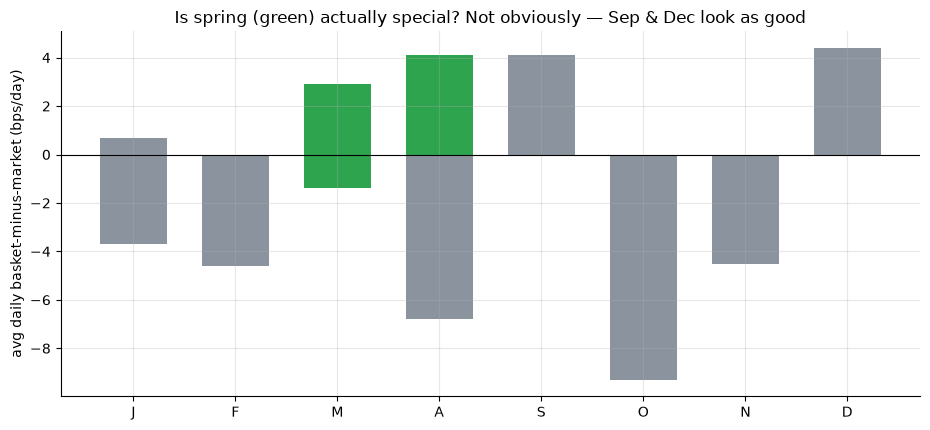

pollen months M/A/M (bps/day): [2.9, 4.1, -1.4]


In [3]:
months = R['months']
ms = [months[m][0] for m in range(1, 13)]
labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
fig, ax = plt.subplots(figsize=(9.4, 4.4))
cols = [GREEN if m in (3,4,5) else GREY for m in range(1,13)]
ax.bar(labels, ms, color=cols, width=.66)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('avg daily basket-minus-market (bps/day)')
ax.set_title('Is spring (green) actually special? Not obviously — Sep & Dec look as good')
plt.tight_layout(); plt.show()
print('pollen months M/A/M (bps/day):', [months[m][0] for m in (3,4,5)])

Here's the catch. The "spring beats a random window" result isn't because spring is a goldmine — it's because the basket **quietly lags the market for much of the rest of the year** (a random 3-month window averages about **-107 bps**). Against that soggy baseline, a merely *flat* spring looks great. Month by month, March and April lean mildly positive — but so do September and December, and none of them stand out from the noise. There's no clean "the pollen months light up" picture.

**Finally, the trade.** Could you bank the +2% with a long/short?

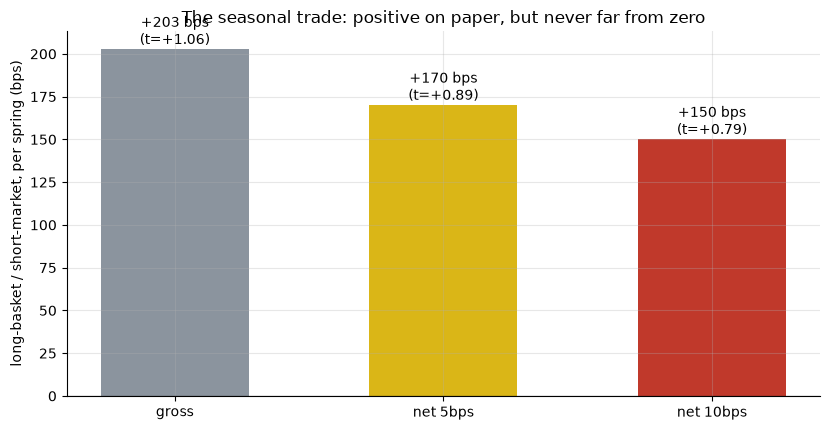

long/short per spring (bps): {'gross': 203.0, 'net 5bps': 170.4, 'net 10bps': 150.4}


In [4]:
if HAVE_REAL:
    holds = ['gross', 'net 5bps', 'net 10bps']
    g = st.timer_stats(st.build_spread_table(PRICES, YEARS, cost_bps=0.0))
    n5 = st.timer_stats(st.build_spread_table(PRICES, YEARS, cost_bps=5.0))
    n10 = st.timer_stats(st.build_spread_table(PRICES, YEARS, cost_bps=10.0))
    vals = [g['gross_mean_bps'], n5['net_mean_bps'], n10['net_mean_bps']]
    tsv = [g['gross_t'], n5['net_t'], n10['net_t']]
else:
    holds = ['gross', 'net 5bps', 'net 10bps']
    vals = [R['gross_bps'], R['net5_bps'], R['net10_bps']]
    tsv = [R['gross_t'], R['net5_t'], R['net10_t']]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(holds, vals, color=[GREY, AMBER, RED], width=.55)
for i, (v, t) in enumerate(zip(vals, tsv)):
    ax.annotate(f'{v:+.0f} bps\n(t={t:+.2f})', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('long-basket / short-market, per spring (bps)')
ax.set_title('The seasonal trade: positive on paper, but never far from zero')
plt.tight_layout(); plt.show()
print('long/short per spring (bps):', dict(zip(holds, [round(v,1) for v in vals])))

The long/short earns a gross **+2.03%/yr** — but at *t* = **1.06** you can't distinguish it from zero *before you pay a cent*. Charge the spread on both legs and borrow on the short and it fades to **+1.70%** (*t* = 0.89). There's simply no edge solid enough to size — a +2% average that swings ±20% year to year is not a trade, it's a coin flip with a slight tilt.

## 5 · The verdict

- **Signal — None.** The basket beats the market by **+2.03%** in the average spring (63% hit rate) — the right sign, but at *t* = **1.06** over 30 years it's indistinguishable from zero, and the one borderline "luck check" rides on the basket's *off-season* weakness, not a real spring edge.
- **Tradability — Mirage.** The seasonal long/short is positive on paper but undistinguishable from zero before costs, and worse after them.
- **"A tradable spring seasonal?" — Not supported.** The direction leans the folklore's way; the certainty never arrives.

## 6 · Going further 🚪

- **This doesn't say the demand spike is fake** — it plainly isn't; people really do buy more allergy medicine in spring. It says that *known, calendar-predictable* demand is largely already in the price, leaving no seasonal a date-watcher can bank at this sample size.
- **Where a real version might hide:** the pure OTC-brand names (Kenvue, Haleon) rather than diversified pharma giants where allergy is a rounding error; a pollen-*intensity* signal (a bad pollen year vs a mild one) instead of a fixed calendar; or the quarterly earnings-surprise angle rather than a price window.
- **Sibling studies:** [708-eurovision-effect](../../708-eurovision-effect/) and [707-plane-crash-effect](../../707-plane-crash-effect/) share the exact event-study machinery (one-sample *t*, random placebo, costed timer, synthetic control) on very different folklore.

*Think the pure-OTC names or a pollen-intensity signal would separate spring from the noise? Show it — out of sample, after costs — then we'll talk.*